In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

TRAIN_DATASET_DIR = "./learn_dataset_single_object"  # 学習: 単一物体
TEST_DATASET_DIR  = "./learn_dataset_fixed_angle"     # テスト: 2物体同時
TRAIN_META_CSV = os.path.join(TRAIN_DATASET_DIR, "metadata.csv")
TEST_META_CSV  = os.path.join(TEST_DATASET_DIR,  "metadata.csv")
MODEL_PATH = "./best_detector_agnostic.pt"

N_FIXED      = 10
FIXED_ANGLES = np.linspace(-5, 5, N_FIXED)  # 角度グリッド [度]
SIGMA_ANGLE  = 0.3                           # 角度方向Gaussianの標準偏差 [度]

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
EPOCHS     = 30
LR         = 1e-4

D_TOL = 2
R_TOL = 3

print("DEVICE:", DEVICE)
print("TRAIN_META_CSV exists:", os.path.exists(TRAIN_META_CSV))
print("TEST_META_CSV  exists:", os.path.exists(TEST_META_CSV))
print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark = False
torch.cuda.empty_cache()
print(f"allocated: {torch.cuda.memory_allocated()/1024**2:.0f} MB")
print(f"reserved:  {torch.cuda.memory_reserved()/1024**2:.0f} MB")

DEVICE: cuda
TRAIN_META_CSV exists: True
TEST_META_CSV  exists: True
True
NVIDIA GeForce RTX 3060 Ti
allocated: 21 MB
reserved:  40 MB


In [50]:
def Radar_setting():
    ###### symbol time & carrier frequency ######
    T_symbol = 5.575 * 1e-6              # symbol duration, with CP time
    T_OFDM = 5.2125 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545*1e-9                      # sampling time

    ###### tx/rx ######
    N_ant = 16                       # the number of antennas
    # BW = 1.966080e+9                      # chirp bandwidth
    BW = 400*1e+6                    # chirp bandwidth
    BW_sub = BW/N_ant
    N_sample = int(np.floor(T_symbol/Tc))           # the number of samples of single chirp
    rx_sample = 813 + N_sample

    ###### Radar setting ######

    mu = BW_sub/T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed/f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol,f_carrier,Tc,N_ant,BW,BW_sub,N_sample,rx_sample, mu, l_speed, lam, env

In [51]:
def MUSIC_method_improved(Y, N_ant, num_signals, frame_count):
    '''
    修正前
    Y_music = np.mean(Y, axis=0)
    R_yy = Y_music@np.conjugate(np.transpose(Y_music))
    '''
    # 修正後: 
    # チャープ軸(0)とサンプル軸(2)の両方を「スナップショット」として扱います。
    # (N_trans, N_ant, N_sample) -> (N_ant, N_trans * N_sample) に変形
    # これにより、N_trans(チャープ数)が増えるほど、スナップショット数が増え、
    # 共分散行列 R_yy の推定精度が向上します。
    N_trans, N_ant_data, N_sample = Y.shape
    # データを (アンテナ数 x 全サンプル数) の2次元行列に変形
    Y_music = Y.transpose(1, 0, 2).reshape(N_ant_data, -1)
    
    # 共分散行列の計算
    # (行列サイズは アンテナ数 x アンテナ数 のまま変わらないので計算負荷は軽微です)
    R_yy = (Y_music @ np.conjugate(Y_music.T)) / Y_music.shape[1]
    
    # 1.固有値分解
    eig_val, eig_vec = np.linalg.eig(R_yy)
    
    # 2.固有値をソートして雑音部分空間を取得
    idx = np.abs(eig_val).argsort()[::-1]
    # インデックスによって固有値と固有ベクトルの対応関係を維持しつつソート
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 雑音部分空間Uを取得

    # num_signalsを固有値から推定?
    
    # デバッグ用
    num_signals = 5
    
    U = eig_vec[:, num_signals:]
    

    # 3.雑音部分空間とvalごとのステアリングベクトルの内積を計算
    resp = []
    argm = (np.arange(1800)-900)/100
    for val in argm:
        # ステアリングベクトルの計算
        stv = stevec(N_ant, val*np.pi/180)
        # 雑音部分空間との内積
        p = stv.T@U
        # L2ノルムの二乗を計算(pp^H)
        pp = p*np.conjugate(np.transpose(p))
        # A1は行列を1次元配列に変換するメソッド
        # respに逆数を追加
        # 分子は角度推定の上では不要なので省略している
        resp.append(1/(np.abs(pp)**2).A1)
    
    # 4.ピーク検出
    M = np.max(resp)
    
    # デバッグ用
    #MUSIC_method_Debug(eig_val, N_ant, num_signals, resp, argm, M, frame_count)
    
    est_ang = []
    # 三点比較によるピーク検出
    a, b = resp[0][0], resp[1][0]
    for i in range(1,len(argm)-1):
        c = resp[i+1][0]
        #if a < b and b > c and b > 0.2 * M:
        if a < b and b > c and b > 0.00001 * M:
            est_ang.append(argm[i])
        a, b = b, c
    return est_ang

In [52]:
class MultiTargetDataset(Dataset):
    def __init__(self, meta_df):
        self.meta_df = meta_df.reset_index(drop=True)
        # 学習開始前に全データをRAMに読み込む（毎バッチのディスクI/Oを排除）
        self.samples = []
        print(f"データ読み込み中... ({len(self.meta_df)} サンプル)", flush=True)
        for idx in range(len(self.meta_df)):
            row = self.meta_df.iloc[idx]
            npz_path = row["file"]
            if not os.path.isabs(npz_path):
                npz_path = os.path.normpath(os.path.join(".", npz_path))

            data = np.load(npz_path)
            rd_maps = data["rd_maps"]
            x = np.stack(
                [20.0 * np.log10(np.maximum(np.abs(rd_maps[i]).astype(np.float32), 1e-12))
                 for i in range(rd_maps.shape[0])],
                axis=0
            )  # (N_FIXED, H, W)
            H, W = x.shape[1], x.shape[2]

            fixed_angles = data["fixed_angles"] if "fixed_angles" in data else FIXED_ANGLES

            valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
            valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0

            cy_angle = float(data["cyclist_true_angle_deg"]) if (valid_cy and "cyclist_true_angle_deg" in data) else 0.0
            ve_angle = float(data["vehicle_true_angle_deg"]) if (valid_ve and "vehicle_true_angle_deg" in data) else 0.0

            cy_heatmap = make_gaussian_heatmap(H, W, int(row["cyclist_true_d_idx"]), int(row["cyclist_true_r_idx"])) if valid_cy else np.zeros((H, W), dtype=np.float32)
            ve_heatmap = make_gaussian_heatmap(H, W, int(row["vehicle_true_d_idx"]), int(row["vehicle_true_r_idx"])) if valid_ve else np.zeros((H, W), dtype=np.float32)

            # cy/ve を独立したヒートマップに分離（クラス別分離でマッチング不要にする）
            y_cy = np.zeros((N_FIXED, H, W), dtype=np.float32)
            y_ve = np.zeros((N_FIXED, H, W), dtype=np.float32)
            if valid_cy:
                cy_ch = int(np.argmin(np.abs(fixed_angles - cy_angle)))
                y_cy[cy_ch] = np.clip(y_cy[cy_ch] + cy_heatmap, 0.0, 1.0)
            if valid_ve:
                ve_ch = int(np.argmin(np.abs(fixed_angles - ve_angle)))
                y_ve[ve_ch] = np.clip(y_ve[ve_ch] + ve_heatmap, 0.0, 1.0)

            self.samples.append({
                "x":         torch.from_numpy(x).float(),
                "y_cy":      torch.from_numpy(y_cy).float(),
                "y_ve":      torch.from_numpy(y_ve).float(),
                "cy_true_d": torch.tensor(int(row["cyclist_true_d_idx"]), dtype=torch.long),
                "cy_true_r": torch.tensor(int(row["cyclist_true_r_idx"]), dtype=torch.long),
                "ve_true_d": torch.tensor(int(row["vehicle_true_d_idx"]), dtype=torch.long),
                "ve_true_r": torch.tensor(int(row["vehicle_true_r_idx"]), dtype=torch.long),
                "valid_cy":  torch.tensor(valid_cy, dtype=torch.long),
                "valid_ve":  torch.tensor(valid_ve, dtype=torch.long),
            })
        print("読み込み完了", flush=True)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


In [53]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)

class RadarLightUNet(nn.Module):
    def __init__(self, in_channels=N_FIXED, out_channels=2, fixed_channels=32, dropout=0.1):
        super().__init__()

        self.n_angles = out_channels

        self.encoders = nn.ModuleList([
            ConvBlock(in_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
        ])
        self.pools = nn.ModuleList([
            nn.MaxPool2d(2, 2) for _ in range(4)
        ])
        self.bottleneck = ConvBlock(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        # 各角度chに独立したヘッド: 共有特徴(fixed_channels) + 対応入力RDマップ(1ch) → 1ch
        self.angle_heads = nn.ModuleList([
            nn.Conv2d(fixed_channels + 1, 1, kernel_size=1)
            for _ in range(out_channels)
        ])

    def forward(self, x):
        x_input = x  # (B, N_FIXED, H, W)

        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        outs = [
            head(torch.cat([x, x_input[:, i:i+1]], dim=1))
            for i, head in enumerate(self.angle_heads)
        ]
        return torch.cat(outs, dim=1)  # (B, N_FIXED, H, W)


# ===== 3D畳み込みモデル (強度をチャネル) =====

class ConvBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout3d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class RadarUNet3DIntensity(nn.Module):
    """
    強度を1chとし、(angle, Doppler, Range)を3次元空間として扱うUNet。
    cy/ve を独立したヒートマップヘッドで出力し、存在確率を別ヘッドで学習する。
    exist_head により valid_cy/ve=0 のとき明示的に抑制される。
    """
    def __init__(self, n_angles=N_FIXED, fixed_channels=32, dropout=0.1):
        super().__init__()
        self.n_angles = n_angles

        # 入力: (B, 1, N_FIXED, H, W) — 強度1ch、角度は空間次元
        self.encoders = nn.ModuleList([
            ConvBlock3D(1,              fixed_channels, dropout),
            ConvBlock3D(fixed_channels, fixed_channels, dropout),
            ConvBlock3D(fixed_channels, fixed_channels, dropout),
            ConvBlock3D(fixed_channels, fixed_channels, dropout),
        ])
        # 角度軸はプールしない（N_FIXED=10が小さいため）
        self.pools = nn.ModuleList([
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)) for _ in range(4)
        ])
        self.bottleneck = ConvBlock3D(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=(1, 2, 2), mode="trilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock3D(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        # cy/ve クラス別ヒートマップヘッド
        self.cy_head = nn.Conv3d(fixed_channels, 1, kernel_size=1)
        self.ve_head = nn.Conv3d(fixed_channels, 1, kernel_size=1)
        # cy/ve 存在確率ヘッド（valid_cy/ve で直接監督）
        # decoder特徴全体をGAPして存在を独立に学習する
        self.cy_exist_head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),   # (B, C, N, H, W) → (B, C, 1, 1, 1)
            nn.Flatten(),              # (B, C)
            nn.Linear(fixed_channels, 1),  # (B, 1)
        )
        self.ve_exist_head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(fixed_channels, 1),
        )

    def forward(self, x):
        # x: (B, N_FIXED, H, W) → (B, 1, N_FIXED, H, W)
        x_3d = x.unsqueeze(1)

        skips = []
        feat = x_3d
        for enc, pool in zip(self.encoders, self.pools):
            feat = enc(feat)
            skips.append(feat)
            feat = pool(feat)
        feat = self.bottleneck(feat)
        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            feat = up(feat)
            if feat.shape[-3:] != skip.shape[-3:]:
                feat = F.interpolate(feat, size=skip.shape[-3:], mode="trilinear", align_corners=False)
            feat = torch.cat([feat, skip], dim=1)
            feat = dec(feat)

        # クラス別ヒートマップ: (B, 1, N_FIXED, H, W) → (B, N_FIXED, H, W)
        cy_logits = self.cy_head(feat).squeeze(1)  # (B, N_FIXED, H, W)
        ve_logits = self.ve_head(feat).squeeze(1)  # (B, N_FIXED, H, W)
        # 存在確率 raw logit: (B,)
        cy_exist = self.cy_exist_head(feat).squeeze(1)  # (B,)
        ve_exist = self.ve_exist_head(feat).squeeze(1)  # (B,)
        return cy_logits, ve_logits, cy_exist, ve_exist


In [54]:
# 学習用: 単一物体(280train+60val) + 2物体(170train+30val) / テスト: 2物体(100test)
RANDOM_SEED = 42

# --- 単一物体データ ---
single_df = pd.read_csv(TRAIN_META_CSV)
single_df = single_df[single_df["valid_all"] == 1].reset_index(drop=True)
single_df = single_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
single_train_df = single_df.iloc[:280].reset_index(drop=True)
single_val_df   = single_df.iloc[280:340].reset_index(drop=True)

# --- 2物体データ ---
two_df = pd.read_csv(TEST_META_CSV)
two_df = two_df[two_df["valid_all"] == 1].reset_index(drop=True)
two_df = two_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
two_train_df = two_df.iloc[:170].reset_index(drop=True)
two_val_df   = two_df.iloc[170:200].reset_index(drop=True)  # 2物体valを追加
test_df      = two_df.iloc[200:].reset_index(drop=True)

# --- 結合 ---
train_df = pd.concat([single_train_df, two_train_df], ignore_index=True)
val_df   = pd.concat([single_val_df, two_val_df], ignore_index=True)  # 単一+2物体

print(f"train: {len(train_df)}  (単一:{len(single_train_df)}, 2物体:{len(two_train_df)})")
print(f"val:   {len(val_df)}  (単一:{len(single_val_df)}, 2物体:{len(two_val_df)})")
print(f"test:  {len(test_df)}")
display(train_df.head())

train: 450  (単一:280, 2物体:170)
val:   90  (単一:60, 2物体:30)
test:  100


,file,scenario,cyclist_true_d_idx,cyclist_true_r_idx,vehicle_true_d_idx,vehicle_true_r_idx,valid_cyclist,valid_vehicle,valid_all,source_index,cyclist_true_angle_deg,vehicle_true_angle_deg,sample_id,source_index_cyclist,source_index_vehicle,cyclist_true_range,cyclist_true_velocity,vehicle_true_range,vehicle_true_velocity
0,./learn_dataset_single_object\sample_00110.npz,cyclist_only,1,140,0,0,True,0,1,111.0,3.083862,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,./learn_dataset_single_object\sample_00419.npz,vehicle_only,0,0,1,126,0,True,1,157.0,0.000000,1.670286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,./learn_dataset_single_object\sample_00565.npz,vehicle_only,0,0,1,112,0,True,1,213.0,0.000000,1.776413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,./learn_dataset_single_object\sample_00077.npz,cyclist_only,1,149,0,0,True,0,1,78.0,3.008346,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,./learn_dataset_single_object\sample_00181.npz,cyclist_only,1,122,0,0,True,0,1,182.0,3.252356,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
def evaluate_split(model, meta_df, batch_size=BATCH_SIZE, device=DEVICE):
    ds = SingleTargetDataset(meta_df.reset_index(drop=True))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    loss, hit = run_epoch(model, loader, optimizer=None, device=device)
    return {
        "count": len(meta_df),
        "loss": loss,
        "hit_rate": hit,
    }

def evaluate_per_kind(model, meta_df, device=DEVICE):
    rows = []

    rows.append({
        "target_kind": "all",
        **evaluate_split(model, meta_df, device=device)
    })

    for target_kind in ["ped", "vehicle"]:
        sub_df = meta_df[meta_df["target_kind"] == target_kind].reset_index(drop=True)
        if len(sub_df) == 0:
            continue

        rows.append({
            "target_kind": target_kind,
            **evaluate_split(model, sub_df, device=device)
        })

    return pd.DataFrame(rows)

In [56]:
def make_gaussian_heatmap(H, W, center_d, center_r, sigma_d=3.0, sigma_r=1.0):
    d = np.arange(H, dtype=np.float32)[:, None]
    r = np.arange(W, dtype=np.float32)[None, :]
    heatmap = np.exp(
        -0.5 * (((d - center_d) / sigma_d) ** 2 + ((r - center_r) / sigma_r) ** 2)
    )
    return heatmap.astype(np.float32)

def load_all_rd_maps(npz_path):
    data = np.load(npz_path)
    rd_maps = data["rd_maps"]
    result = []
    for i in range(rd_maps.shape[0]):
        rd_mag = np.abs(rd_maps[i]).astype(np.float32)
        rd_db = 20.0 * np.log10(np.maximum(rd_mag, 1e-12))
        result.append(rd_db)
    return np.stack(result, axis=0)

def decode_class_detections(cy_logits, ve_logits, cy_exist, ve_exist):
    """
    cy/ve クラス別ヒートマップと存在 logit から検出点を返す。
    exist ヘッドの出力 (sigmoid > 0.5) で存在判定し、argmax で位置を決定する。
    引数はすべてバッチ入り (1, ...) のテンソル。
    戻り値: cy_det=(ch,d,r), ve_det=(ch,d,r)。検出なしは (-1,-1,-1)。
    """
    def _detect(logits, exist_logit):
        if torch.sigmoid(exist_logit[0]).item() < 0.5:
            return (-1, -1, -1)
        prob = torch.sigmoid(logits[0])  # (N_FIXED, H, W)
        C, H, W = prob.shape
        flat_idx = torch.argmax(prob).item()
        ch = flat_idx // (H * W)
        rem = flat_idx % (H * W)
        d = rem // W
        r = rem % W
        return (ch, d, r)

    return _detect(cy_logits, cy_exist), _detect(ve_logits, ve_exist)

def compute_hit(pred_d, pred_r, true_d, true_r, d_tol=D_TOL, r_tol=R_TOL):
    return (abs(pred_d - true_d) <= d_tol) and (abs(pred_r - true_r) <= r_tol)


In [57]:
CENTERNET_ALPHA = 2  # 正例のfocal weight
CENTERNET_BETA  = 4  # Gaussian裾野の罰則緩和度（峰に近いほど負例罰則を弱める）

def centernet_focal_loss(logits, targets, alpha=CENTERNET_ALPHA, beta=CENTERNET_BETA):
    # CenterNet式: Gaussianラベルに対してFocal Lossをかける
    # 正例(y=1):  -(1-p)^alpha * log(p)
    # 裾野(y<1):  -(1-y)^beta * p^alpha * log(1-p)  yで罰則を緩和
    # 正例・負例を別々に平均して同等に扱う（負例数>>正例数の不均衡対策）
    p = torch.sigmoid(logits)
    pos_mask = (targets == 1).float()
    neg_mask = (targets < 1).float()
    pos_loss = -(1 - p).pow(alpha) * torch.log(p.clamp(min=1e-6)) * pos_mask
    neg_loss = -(1 - targets).pow(beta) * p.pow(alpha) * torch.log((1 - p).clamp(min=1e-6)) * neg_mask
    n_pos = pos_mask.sum().clamp(min=1)
    n_neg = neg_mask.sum().clamp(min=1)
    return pos_loss.sum() / n_pos + neg_loss.sum() / n_neg

def compute_loss(cy_logits, ve_logits, y_cy, y_ve, cy_exist, ve_exist, valid_cy, valid_ve):
    # ヒートマップ損失（位置学習）
    heatmap_loss = centernet_focal_loss(cy_logits, y_cy) + centernet_focal_loss(ve_logits, y_ve)
    # 存在確率損失（valid_cy/ve で直接監督）
    exist_loss = (
        F.binary_cross_entropy_with_logits(cy_exist, valid_cy.float()) +
        F.binary_cross_entropy_with_logits(ve_exist, valid_ve.float())
    )
    return heatmap_loss + exist_loss

def run_epoch(model, loader, optimizer=None, device='cpu'):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    cy_hits, cy_total = 0, 0
    ve_hits, ve_total = 0, 0
    print("Epoch start. Train mode:", train_mode)

    for batch_idx, batch in enumerate(loader):
        x         = batch['x'].to(device)
        y_cy      = batch['y_cy'].to(device)          # (B, N_FIXED, H, W)
        y_ve      = batch['y_ve'].to(device)          # (B, N_FIXED, H, W)
        valid_cy_t = batch['valid_cy'].to(device)     # (B,) 存在損失用
        valid_ve_t = batch['valid_ve'].to(device)     # (B,)
        cy_true_d = batch['cy_true_d'].cpu().numpy()
        cy_true_r = batch['cy_true_r'].cpu().numpy()
        ve_true_d = batch['ve_true_d'].cpu().numpy()
        ve_true_r = batch['ve_true_r'].cpu().numpy()
        valid_cy  = batch['valid_cy'].cpu().numpy()
        valid_ve  = batch['valid_ve'].cpu().numpy()

        if train_mode:
            optimizer.zero_grad()

        cy_logits, ve_logits, cy_exist, ve_exist = model(x)
        loss = compute_loss(cy_logits, ve_logits, y_cy, y_ve,
                            cy_exist, ve_exist, valid_cy_t, valid_ve_t)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item() * x.size(0)

        for i in range(x.size(0)):
            cy_det, ve_det = decode_class_detections(
                cy_logits[i:i+1].detach().cpu(),
                ve_logits[i:i+1].detach().cpu(),
                cy_exist[i:i+1].detach().cpu(),
                ve_exist[i:i+1].detach().cpu(),
            )
            cy_d, cy_r = cy_det[1], cy_det[2]
            ve_d, ve_r = ve_det[1], ve_det[2]
            if valid_cy[i]:
                cy_hits  += int(compute_hit(cy_d, cy_r, int(cy_true_d[i]), int(cy_true_r[i])))
                cy_total += 1
            if valid_ve[i]:
                ve_hits  += int(compute_hit(ve_d, ve_r, int(ve_true_d[i]), int(ve_true_r[i])))
                ve_total += 1

    n = len(loader.dataset)
    mean_loss   = total_loss / max(n, 1)
    cy_hit_rate = cy_hits / max(cy_total, 1)
    ve_hit_rate = ve_hits / max(ve_total, 1)
    return mean_loss, cy_hit_rate, ve_hit_rate


In [58]:
# === 学習モード切り替え ===
# False: 単一物体(learn_dataset_single_object) + 2物体(learn_dataset_fixed_angle) の混合
# True:  単一物体のみ(learn_dataset_single_angle, 角度情報付き) で学習
SINGLE_ONLY = False

if SINGLE_ONLY:
    sa_df = pd.read_csv("./learn_dataset_single_angle/metadata.csv")
    sa_df = sa_df[sa_df["valid_all"] == 1].reset_index(drop=True)
    sa_df = sa_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    _train_df = sa_df.iloc[:280].reset_index(drop=True)
    _val_df   = sa_df.iloc[280:340].reset_index(drop=True)
    MODEL_PATH = "./best_detector_3d_exist_head_single.pt"
    print(f"モード: 単一物体のみ  train={len(_train_df)}  val={len(_val_df)}")
else:
    _train_df = train_df
    _val_df   = val_df
    MODEL_PATH = "./best_detector_3d_exist_head.pt"
    print(f"モード: 混合  train={len(_train_df)}  val={len(_val_df)}")

train_ds = MultiTargetDataset(_train_df)
val_ds   = MultiTargetDataset(_val_df)
test_ds  = MultiTargetDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model = RadarUNet3DIntensity(n_angles=N_FIXED).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float("inf")
history = []

for epoch in range(EPOCHS):
    train_loss, train_cy_hit, train_ve_hit = run_epoch(model, train_loader, optimizer=optimizer, device=DEVICE)
    val_loss,   val_cy_hit,   val_ve_hit   = run_epoch(model, val_loader,   optimizer=None,      device=DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_cy_hit": train_cy_hit,
        "train_ve_hit": train_ve_hit,
        "val_loss": val_loss,
        "val_cy_hit": val_cy_hit,
        "val_ve_hit": val_ve_hit,
    })

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"epoch={epoch+1:02d} "
        f"train_loss={train_loss:.4f} cy={train_cy_hit:.3f} ve={train_ve_hit:.3f} | "
        f"val_loss={val_loss:.4f}   cy={val_cy_hit:.3f} ve={val_ve_hit:.3f}"
    )

print("best model saved to:", MODEL_PATH)
hist_df = pd.DataFrame(history)
display(hist_df.tail())

モード: 混合  train=450  val=90
データ読み込み中... (450 サンプル)
読み込み完了
データ読み込み中... (90 サンプル)
読み込み完了
データ読み込み中... (100 サンプル)
読み込み完了
Epoch start. Train mode: True
Epoch start. Train mode: False
epoch=01 train_loss=1.4723 cy=0.073 ve=0.039 | val_loss=1.2958   cy=0.000 ve=0.000
Epoch start. Train mode: True
Epoch start. Train mode: False
epoch=02 train_loss=1.3167 cy=0.342 ve=0.132 | val_loss=1.3173   cy=0.821 ve=0.578
Epoch start. Train mode: True
Epoch start. Train mode: False
epoch=03 train_loss=1.2961 cy=0.839 ve=0.362 | val_loss=1.3251   cy=0.804 ve=0.312
Epoch start. Train mode: True
Epoch start. Train mode: False
epoch=04 train_loss=1.3044 cy=0.829 ve=0.543 | val_loss=1.3548   cy=0.857 ve=0.453
Epoch start. Train mode: True
Epoch start. Train mode: False
epoch=05 train_loss=1.2892 cy=0.794 ve=0.497 | val_loss=1.3034   cy=0.732 ve=0.438
Epoch start. Train mode: True
Epoch start. Train mode: False
epoch=06 train_loss=1.2750 cy=0.785 ve=0.602 | val_loss=1.2740   cy=0.625 ve=0.562
Epoch start. Train m

,epoch,train_loss,train_cy_hit,train_ve_hit,val_loss,val_cy_hit,val_ve_hit
25,26,0.307380,0.933544,0.355263,0.063043,0.928571,0.031250
26,27,0.289249,0.905063,0.371711,0.066716,0.892857,0.453125
27,28,0.452185,0.927215,0.328947,0.080356,0.928571,0.296875
28,29,0.290112,0.962025,0.378289,0.554238,0.982143,0.484375
29,30,0.324388,0.949367,0.361842,0.156161,0.946429,0.218750


In [68]:
best_model = RadarUNet3DIntensity(n_angles=N_FIXED).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_cy_hit, test_ve_hit = run_epoch(best_model, test_loader, optimizer=None, device=DEVICE)
print(f"test_loss={test_loss:.4f}  cyclist_hit={test_cy_hit:.3f}  vehicle_hit={test_ve_hit:.3f}")

Epoch start. Train mode: False
test_loss=0.2371  cyclist_hit=0.930  vehicle_hit=0.330


=== sample 15 ===
[cy exist] 0.963  det=(8, 1, 152)
[ve exist] 1.000  det=(6, 1, 140)
[true] cyclist=(1,152,2.9790654327517405)  vehicle=(1,145,1.5363548338708128)


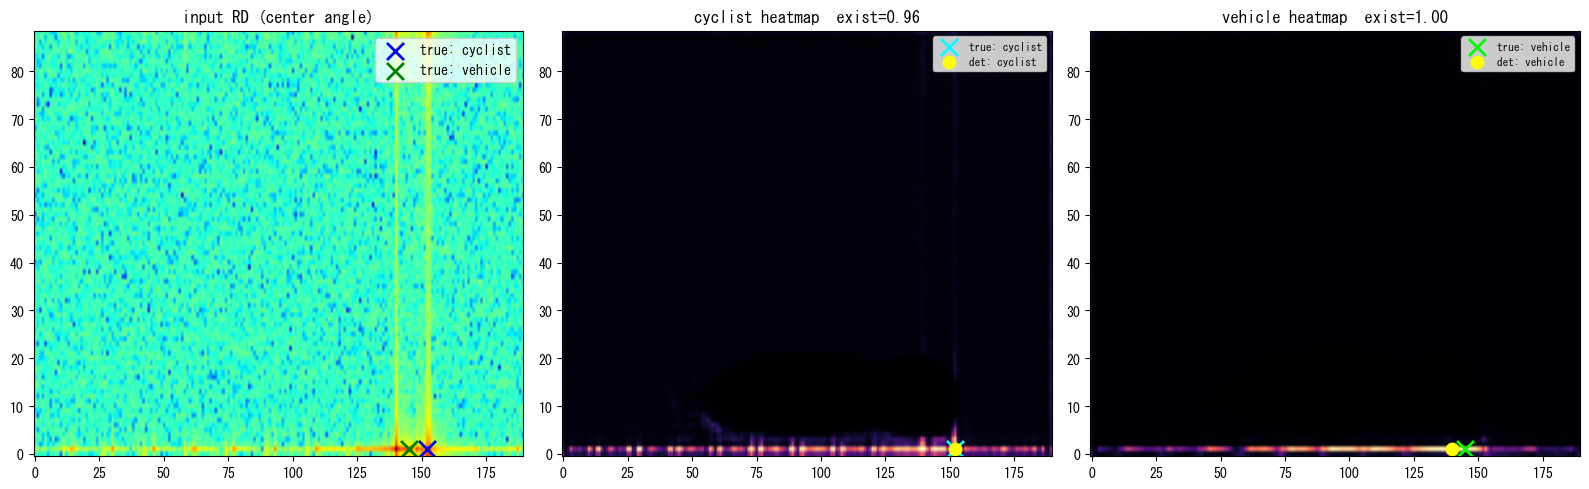

=== sample 30 ===
[cy exist] 0.999  det=(8, 1, 158)
[ve exist] 0.995  det=(6, 1, 164)
[true] cyclist=(1,158,2.9234826320697187)  vehicle=(1,163,1.415826906653283)


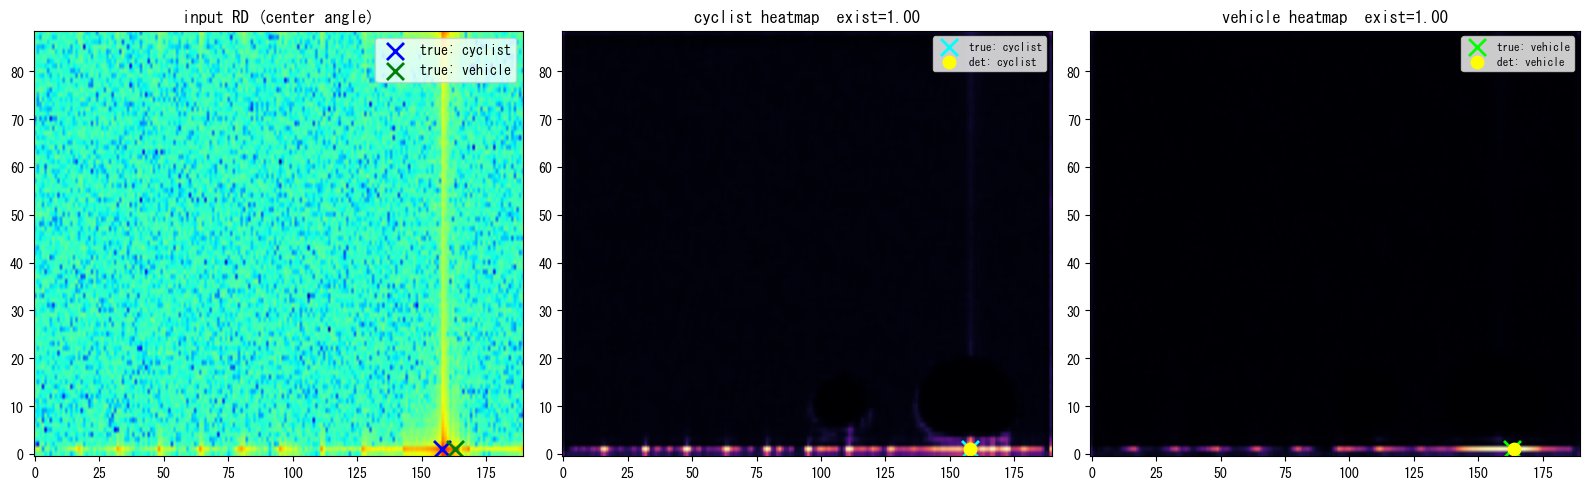

In [69]:
def show_prediction(sample_idx=0):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        cy_logits, ve_logits, cy_exist, ve_exist = best_model(x_tensor)

    cy_det, ve_det = decode_class_detections(
        cy_logits.cpu(), ve_logits.cpu(), cy_exist.cpu(), ve_exist.cpu())

    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    cy_true_a = float(row["cyclist_true_angle_deg"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])
    ve_true_a = float(row["vehicle_true_angle_deg"])

    print(f"=== sample {sample_idx} ===")
    print(f"[cy exist] {torch.sigmoid(cy_exist[0]).item():.3f}  det={cy_det}")
    print(f"[ve exist] {torch.sigmoid(ve_exist[0]).item():.3f}  det={ve_det}")
    print(f"[true] cyclist=({cy_true_d},{cy_true_r},{cy_true_a})  vehicle=({ve_true_d},{ve_true_r},{ve_true_a})")

    rd_db      = x[N_FIXED // 2]
    cy_heatmap = torch.sigmoid(cy_logits)[0].max(dim=0).values.cpu().numpy()
    ve_heatmap = torch.sigmoid(ve_logits)[0].max(dim=0).values.cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(cy_heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[1].scatter([cy_true_r], [cy_true_d], c="cyan", marker="x", s=150, linewidths=2, label="true: cyclist")
    if cy_det[0] >= 0:
        axes[1].scatter([cy_det[2]], [cy_det[1]], c="yellow", marker="o", s=80, label="det: cyclist")
    axes[1].set_title(f"cyclist heatmap  exist={torch.sigmoid(cy_exist[0]).item():.2f}")
    axes[1].legend(fontsize=8)

    axes[2].imshow(ve_heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[2].scatter([ve_true_r], [ve_true_d], c="lime", marker="x", s=150, linewidths=2, label="true: vehicle")
    if ve_det[0] >= 0:
        axes[2].scatter([ve_det[2]], [ve_det[1]], c="yellow", marker="o", s=80, label="det: vehicle")
    axes[2].set_title(f"vehicle heatmap  exist={torch.sigmoid(ve_exist[0]).item():.2f}")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_prediction(sample_idx=15)
show_prediction(sample_idx=30)


scenario: cyclist_only
[cy exist] 1.000  det=(8, 1, 168)
[ve exist] 0.008  det=(-1, -1, -1)


C:\Users\kosuke\AppData\Local\Temp\ipykernel_18088\1448954098.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)


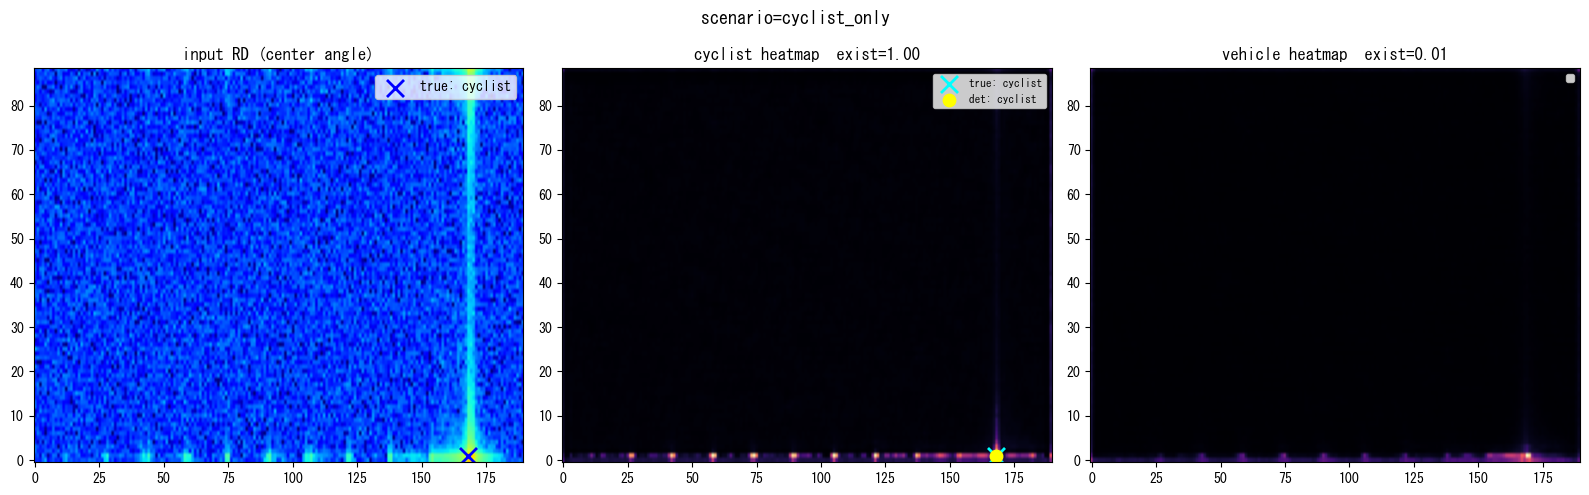

scenario: vehicle_only
[cy exist] 0.006  det=(-1, -1, -1)
[ve exist] 1.000  det=(6, 1, 94)


C:\Users\kosuke\AppData\Local\Temp\ipykernel_18088\1448954098.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8)


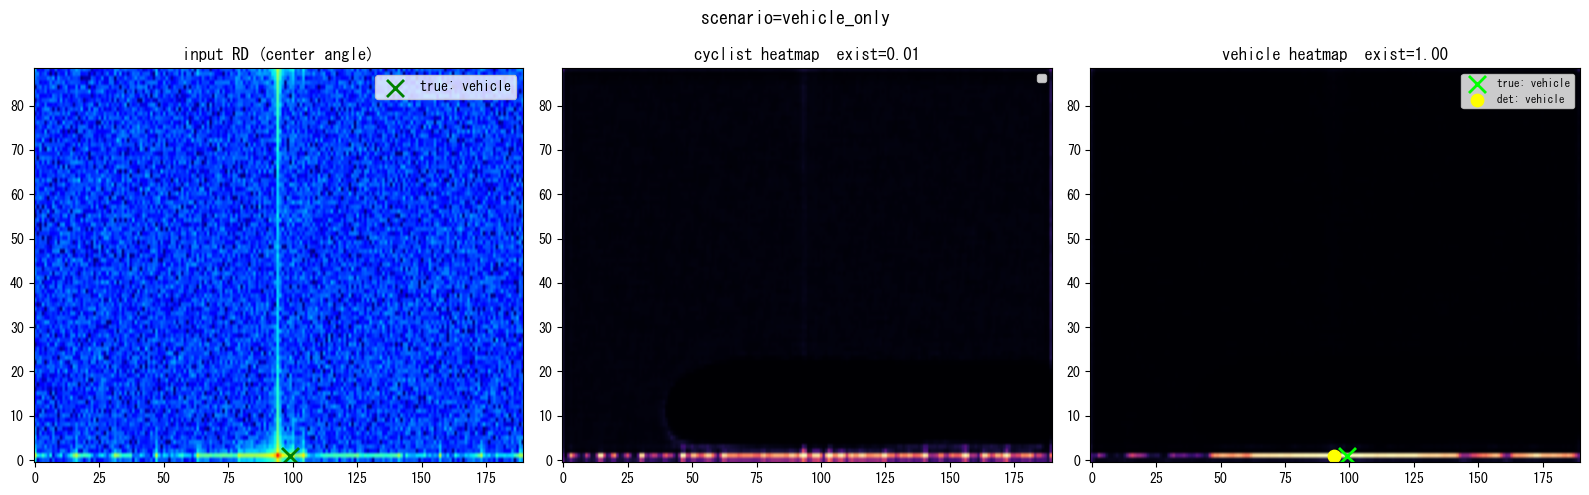

In [70]:
def show_channel_suppression(scenario, sample_idx=0):
    single_df = pd.read_csv("./learn_dataset_single_object/metadata.csv")
    single_df = single_df[single_df["scenario"] == scenario].reset_index(drop=True)
    row = single_df.iloc[sample_idx]

    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        cy_logits, ve_logits, cy_exist, ve_exist = best_model(x_tensor)

    cy_det, ve_det = decode_class_detections(
        cy_logits.cpu(), ve_logits.cpu(), cy_exist.cpu(), ve_exist.cpu())
    cy_heatmap = torch.sigmoid(cy_logits)[0].max(dim=0).values.cpu().numpy()
    ve_heatmap = torch.sigmoid(ve_logits)[0].max(dim=0).values.cpu().numpy()

    valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
    valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0
    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"scenario: {scenario}")
    print(f"[cy exist] {torch.sigmoid(cy_exist[0]).item():.3f}  det={cy_det}")
    print(f"[ve exist] {torch.sigmoid(ve_exist[0]).item():.3f}  det={ve_det}")

    rd_db = x[N_FIXED // 2]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"scenario={scenario}", fontsize=13)

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet", vmin=-90, vmax=0)
    if valid_cy:
        axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(cy_heatmap, aspect="auto", origin="lower", cmap="magma")
    if valid_cy:
        axes[1].scatter([cy_true_r], [cy_true_d], c="cyan", marker="x", s=150, linewidths=2, label="true: cyclist")
    if cy_det[0] >= 0:
        axes[1].scatter([cy_det[2]], [cy_det[1]], c="yellow", marker="o", s=80, label="det: cyclist")
    axes[1].set_title(f"cyclist heatmap  exist={torch.sigmoid(cy_exist[0]).item():.2f}")
    axes[1].legend(fontsize=8)

    axes[2].imshow(ve_heatmap, aspect="auto", origin="lower", cmap="magma")
    if valid_ve:
        axes[2].scatter([ve_true_r], [ve_true_d], c="lime", marker="x", s=150, linewidths=2, label="true: vehicle")
    if ve_det[0] >= 0:
        axes[2].scatter([ve_det[2]], [ve_det[1]], c="yellow", marker="o", s=80, label="det: vehicle")
    axes[2].set_title(f"vehicle heatmap  exist={torch.sigmoid(ve_exist[0]).item():.2f}")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_channel_suppression("cyclist_only", sample_idx=0)
show_channel_suppression("vehicle_only", sample_idx=0)


scenario test: 31 samples

 step  r_diff   n  cy_found  cy_hit  ve_found  ve_hit
------------------------------------------------------------
    0      11   2         o       o         o       -
    1      11   2         o       o         o       -
    2       9   2         o       o         o       -
    3       9   2         o       o         o       o
    4       9   2         o       o         o       -
    5       9   2         o       -         o       -
    6       7   2         o       o         o       -
    7       7   2         o       o         o       o
    8       7   2         o       o         o       -
    9       6   2         o       o         o       o
   10       6   2         o       o         o       -
   11       5   2         o       -         o       o
   12       5   1         -       -         o       -
   13       4   2         o       o         o       o
   14       4   2         o       -         o       -
   15       3   1         -       -         o   

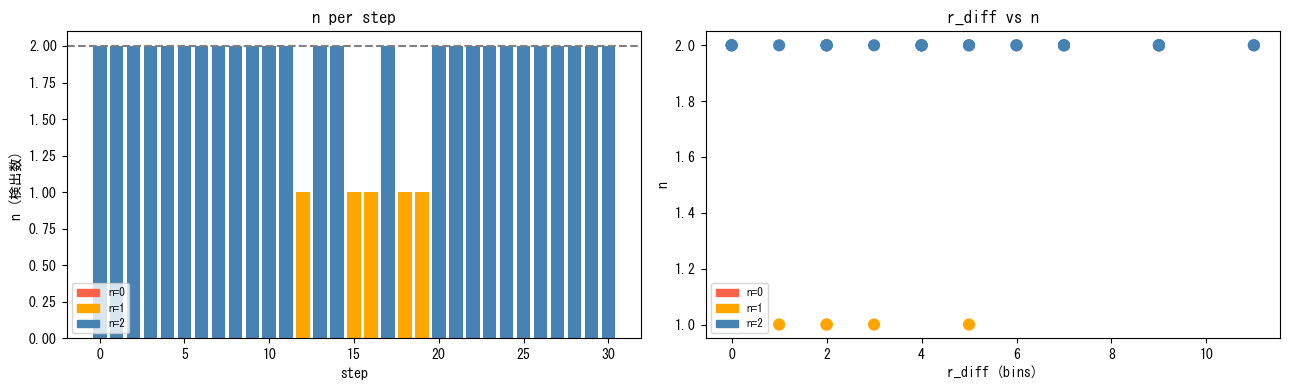

In [71]:
# === scenario test inference ===
import torch, matplotlib.pyplot as plt

SCENARIO_META_CSV = "./learn_dataset_scenario_test/metadata.csv"
scenario_df = pd.read_csv(SCENARIO_META_CSV)
scenario_df = scenario_df[scenario_df["valid_all"] == 1].reset_index(drop=True)
print(f"scenario test: {len(scenario_df)} samples")

rows_sc = []
for i in range(len(scenario_df)):
    row = scenario_df.iloc[i]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        cy_logits, ve_logits, cy_exist, ve_exist = best_model(x_tensor)
    cy_det, ve_det = decode_class_detections(
        cy_logits.cpu(), ve_logits.cpu(), cy_exist.cpu(), ve_exist.cpu())

    cy_true_d = int(row["cyclist_true_d_idx"]); cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"]);  ve_true_r = int(row["vehicle_true_r_idx"])

    cy_found = cy_det[0] >= 0
    ve_found = ve_det[0] >= 0
    cy_hit = cy_found and abs(cy_det[1]-cy_true_d) <= D_TOL and abs(cy_det[2]-cy_true_r) <= R_TOL
    ve_hit = ve_found and abs(ve_det[1]-ve_true_d) <= D_TOL and abs(ve_det[2]-ve_true_r) <= R_TOL
    n = int(cy_found) + int(ve_found)

    rows_sc.append({
        "step": i,
        "cy_r": cy_true_r, "ve_r": ve_true_r,
        "r_diff": abs(cy_true_r - ve_true_r),
        "n": n,
        "cy_found": cy_found, "ve_found": ve_found,
        "cy_hit": cy_hit,   "ve_hit": ve_hit,
        "cy_det": cy_det,   "ve_det": ve_det,
    })

sc_df = pd.DataFrame(rows_sc)

print(f"\n{'step':>5}  {'r_diff':>6}  {'n':>2}  cy_found  cy_hit  ve_found  ve_hit")
print("-" * 60)
for _, r in sc_df.iterrows():
    print(f"{int(r.step):>5}  {int(r.r_diff):>6}  {int(r.n):>2}"
          f"  {'o' if r.cy_found else '-':>8}  {'o' if r.cy_hit else '-':>6}"
          f"  {'o' if r.ve_found else '-':>8}  {'o' if r.ve_hit else '-':>6}")

n0 = (sc_df["n"] == 0).sum()
n1 = (sc_df["n"] == 1).sum()
n2 = (sc_df["n"] == 2).sum()
both_hit = (sc_df["cy_hit"] & sc_df["ve_hit"]).sum()
total = len(sc_df)
print(f"\n=== 検出数の分布 ===")
print(f"n=0 (両方未検出): {n0:>2}/{total} ({n0/total*100:.1f}%)")
print(f"n=1 (片方未検出): {n1:>2}/{total} ({n1/total*100:.1f}%)")
print(f"n=2 (両方検出)  : {n2:>2}/{total} ({n2/total*100:.1f}%)")
print(f"\n=== 位置精度 ===")
print(f"cy_hit (正確に検出): {sc_df.cy_hit.sum():>2}/{total} ({sc_df.cy_hit.mean()*100:.1f}%)")
print(f"ve_hit (正確に検出): {sc_df.ve_hit.sum():>2}/{total} ({sc_df.ve_hit.mean()*100:.1f}%)")
print(f"両方正確          : {both_hit:>2}/{total} ({both_hit/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_map = {0: "tomato", 1: "orange", 2: "steelblue"}
bar_colors = [colors_map.get(int(n), "steelblue") for n in sc_df["n"]]
axes[0].bar(sc_df["step"], sc_df["n"], color=bar_colors)
axes[0].axhline(2, color="gray", linestyle="--", label="expected n=2")
axes[0].set_xlabel("step"); axes[0].set_ylabel("n (検出数)")
axes[0].set_title("n per step")
from matplotlib.patches import Patch
legend_els = [Patch(color=colors_map[k], label=f"n={k}") for k in [0,1,2]]
axes[0].legend(handles=legend_els, fontsize=8)

axes[1].scatter(sc_df["r_diff"], sc_df["n"],
                c=[colors_map.get(int(n), "steelblue") for n in sc_df["n"]], s=60, zorder=3)
axes[1].set_xlabel("r_diff (bins)"); axes[1].set_ylabel("n")
axes[1].set_title("r_diff vs n")
axes[1].legend(handles=legend_els, fontsize=8)

plt.tight_layout()
plt.show()


In [72]:
# === n=2ケースの推定精度 (r/d/angle RMSE) ===
# sc_dfはscenario_evalセルで生成済みであること

import numpy as np

rows_rmse = []
for _, r in sc_df[sc_df["n"] == 2].iterrows():
    step = int(r['step'])
    row = scenario_df.iloc[step]
    cy_det = r['cy_det']
    ve_det = r['ve_det']
    cy_true_angle = float(row['cyclist_true_angle_deg']) if 'cyclist_true_angle_deg' in row.index else float('nan')
    ve_true_angle = float(row['vehicle_true_angle_deg'])  if 'vehicle_true_angle_deg'  in row.index else float('nan')

    rows_rmse.append({
        'step':         step,
        'cy_r_err':     cy_det[2] - int(row['cyclist_true_r_idx']),
        'cy_d_err':     cy_det[1] - int(row['cyclist_true_d_idx']),
        'cy_angle_err': FIXED_ANGLES[cy_det[0]] - cy_true_angle,
        've_r_err':     ve_det[2] - int(row['vehicle_true_r_idx']),
        've_d_err':     ve_det[1] - int(row['vehicle_true_d_idx']),
        've_angle_err': FIXED_ANGLES[ve_det[0]] - ve_true_angle,
    })

rmse_df = pd.DataFrame(rows_rmse)
n2 = len(rmse_df)

def rmse(col): return float(np.sqrt((col ** 2).mean()))

print(f"n=2 ケース: {n2} サンプル  (angle grid spacing = {FIXED_ANGLES[1]-FIXED_ANGLES[0]:.2f} deg)")
print()
print(f"{'':12}  {'r-RMSE':>8}  {'d-RMSE':>8}  {'angle-RMSE':>12}  {'angle-bias':>12}")
print("-" * 60)
print(f"{'cyclist':12}  {rmse(rmse_df.cy_r_err):>8.3f}  {rmse(rmse_df.cy_d_err):>8.3f}  "
      f"{rmse(rmse_df.cy_angle_err):>12.3f}  {rmse_df.cy_angle_err.mean():>+12.3f}")
print(f"{'vehicle':12}  {rmse(rmse_df.ve_r_err):>8.3f}  {rmse(rmse_df.ve_d_err):>8.3f}  "
      f"{rmse(rmse_df.ve_angle_err):>12.3f}  {rmse_df.ve_angle_err.mean():>+12.3f}")
print()
print(f"※ angle-RMSE < {FIXED_ANGLES[1]-FIXED_ANGLES[0]:.2f} deg でグリッド間隔以下の推定精度")


n=2 ケース: 26 サンプル  (angle grid spacing = 1.11 deg)

                r-RMSE    d-RMSE    angle-RMSE    angle-bias
------------------------------------------------------------
cyclist         17.637     0.000         0.610        +0.605
vehicle          4.243     0.000         0.099        -0.037

※ angle-RMSE < 1.11 deg でグリッド間隔以下の推定精度


In [73]:
# === 誤位置検出の分析 ===
# 新設計では n>=3 FP は構造上発生しないため、位置誤り分析に変更

miss_cy = sc_df[~sc_df["cy_hit"]]
miss_ve = sc_df[~sc_df["ve_hit"]]

print(f"=== cyclist ===")
print(f"cy_hit 失敗: {len(miss_cy)}/{len(sc_df)} サンプル")
print(f"  うち未検出 (cy_found=False): {(~miss_cy['cy_found']).sum()}")
print(f"  うち誤位置 (cy_found=True) : {miss_cy['cy_found'].sum()}")
print()
print(f"=== vehicle ===")
print(f"ve_hit 失敗: {len(miss_ve)}/{len(sc_df)} サンプル")
print(f"  うち未検出 (ve_found=False): {(~miss_ve['ve_found']).sum()}")
print(f"  うち誤位置 (ve_found=True) : {miss_ve['ve_found'].sum()}")


=== cyclist ===
cy_hit 失敗: 8/31 サンプル
  うち未検出 (cy_found=False): 5
  うち誤位置 (cy_found=True) : 3

=== vehicle ===
ve_hit 失敗: 26/31 サンプル
  うち未検出 (ve_found=False): 0
  うち誤位置 (ve_found=True) : 26


In [74]:
# === angle channel heatmaps ===
def show_angle_heatmaps(sample_idx=0, dataset_df=scenario_df):
    row = dataset_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    data = np.load(npz_path)
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        cy_logits, ve_logits, cy_exist, ve_exist = best_model(x_tensor)

    cy_det, ve_det = decode_class_detections(
        cy_logits.cpu(), ve_logits.cpu(), cy_exist.cpu(), ve_exist.cpu())

    cy_true_d = int(row["cyclist_true_d_idx"]); cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"]);  ve_true_r = int(row["vehicle_true_r_idx"])
    cy_angle = float(data["cyclist_true_angle_deg"]) if "cyclist_true_angle_deg" in data else float("nan")
    ve_angle = float(data["vehicle_true_angle_deg"]) if "vehicle_true_angle_deg" in data else float("nan")

    print(f"sample {sample_idx}")
    print(f"  [true] cyclist: d={cy_true_d}, r={cy_true_r}, angle={cy_angle:.2f}deg")
    print(f"  [true] vehicle: d={ve_true_d}, r={ve_true_r}, angle={ve_angle:.2f}deg")
    print(f"  [cy exist] {torch.sigmoid(cy_exist[0]).item():.3f}  det={cy_det}")
    print(f"  [ve exist] {torch.sigmoid(ve_exist[0]).item():.3f}  det={ve_det}")

#show_angle_heatmaps(sample_idx=8)
for i in range(16, 21):
    show_angle_heatmaps(sample_idx=i)


sample 16
  [true] cyclist: d=1, r=118, angle=3.29deg
  [true] vehicle: d=1, r=120, angle=1.71deg
  [cy exist] 0.038  det=(-1, -1, -1)
  [ve exist] 1.000  det=(6, 1, 125)
sample 17
  [true] cyclist: d=1, r=117, angle=3.30deg
  [true] vehicle: d=1, r=119, angle=1.72deg
  [cy exist] 0.517  det=(8, 1, 117)
  [ve exist] 1.000  det=(6, 1, 123)
sample 18
  [true] cyclist: d=1, r=116, angle=3.31deg
  [true] vehicle: d=1, r=118, angle=1.73deg
  [cy exist] 0.348  det=(-1, -1, -1)
  [ve exist] 1.000  det=(6, 1, 113)
sample 19
  [true] cyclist: d=1, r=116, angle=3.31deg
  [true] vehicle: d=1, r=117, angle=1.74deg
  [cy exist] 0.062  det=(-1, -1, -1)
  [ve exist] 1.000  det=(6, 1, 125)
sample 20
  [true] cyclist: d=1, r=115, angle=3.32deg
  [true] vehicle: d=1, r=115, angle=1.75deg
  [cy exist] 0.938  det=(8, 1, 114)
  [ve exist] 1.000  det=(6, 1, 110)


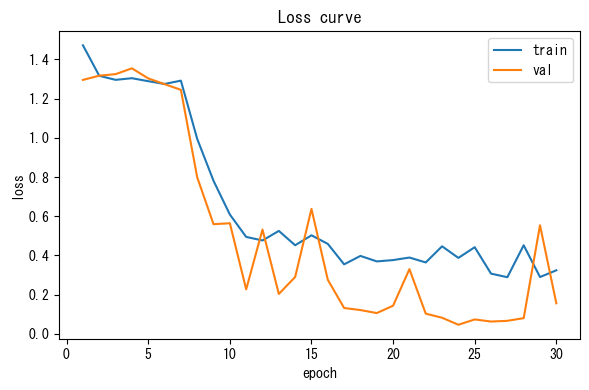

In [75]:
# === 学習曲線 ===
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train")
ax.plot(hist_df["epoch"], hist_df["val_loss"],   label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Loss curve")
ax.legend()

plt.tight_layout()
plt.show()